In [8]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path
import matplotlib.cm as cm
from matplotlib.patches import Polygon, Patch, Rectangle
from scipy.spatial import ConvexHull
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.metrics import pairwise_distances

In [9]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot" #
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" 
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" 
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"


# Functions

## step 1

## step 2

In [37]:

def parse_dot_file(file_path):
    graph = pydot.graph_from_dot_file(file_path)[0]
    adjacency_list = {}

    #list of edges run for each node of the graph

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        if src not in adjacency_list:
            adjacency_list[src] = []
        if dst not in adjacency_list:
            adjacency_list[dst] = []
        adjacency_list[src].append(dst)
        adjacency_list[dst].append(src)  # for undirected graph

    return adjacency_list

def extract_edges(graph):
    edges = []
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            edge = (node, neighbor)
            if edge not in edges and (neighbor, node) not in edges:
                edges.append(edge)
    return edges

def bfs_tree(graph, root):
    visited = set()
    queue = deque([root])
    bfs_tree = {root: []}
    
    while queue:
        node = queue.popleft()
        visited.add(node)

        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                bfs_tree[node].append(neighbor)
                bfs_tree[neighbor] = []
    
    return bfs_tree

def dfs_tree(graph, root, visited=None, tree=None):
    if visited is None:
        visited = set()
    if tree is None:
        tree = {root: []}

    visited.add(root)

    for neighbor in graph.get(root, []):
        if neighbor not in visited:
            tree[root].append(neighbor)
            tree[neighbor] = []
            dfs_tree(graph, neighbor, visited, tree)

    return tree

def missing_edges(spanning_tree, full_edge_list):
    # edges of the spanning tree
    sp_edges = [(node, child) for node, children in spanning_tree.items() for child in children]
    sp_edges_set = set(sp_edges)
    # all edges of the graph
    full_edges_set = set(full_edge_list)
    # edges not present in the spanning tree
    non_tree_edges = full_edges_set - sp_edges_set
    return non_tree_edges

def compute_postorder_spacing(tree, node, spacing, boundaries, min_separation=1.0):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree or not tree[node]:  # No children
        boundaries[node] = (spacing[node], spacing[node])
        return
    
    children = tree[node]
    
    # Process all children first
    for child in children:
        compute_postorder_spacing(tree, child, spacing, boundaries, min_separation)
    
    # Special handling for nodes with 3+ children
    if len(children) >= 3:
        # Ensure adequate spacing between all children
        for i in range(len(children) - 1):
            current_child = children[i]
            next_child = children[i + 1]
            
            # Get current right boundary and next left boundary
            _, current_right = boundaries[current_child]
            next_left, _ = boundaries[next_child]
            
            # If children are too close, shift the next child and all its subtree
            if next_left - current_right < min_separation:
                shift_amount = (current_right + min_separation) - next_left
                
                # Shift the next child and all nodes in its subtree
                shift_subtree(tree, next_child, shift_amount, spacing, boundaries)
    
    # Calculate leftmost and rightmost boundaries from children
    leftmost = min(boundaries[child][0] for child in children)
    rightmost = max(boundaries[child][1] for child in children)
    
    # Center the parent node with respect to its children
    midpoint = (leftmost + rightmost) / 2
    spacing[node] = midpoint
    
    # Set the parent's boundaries to encompass all children
    # Add some padding to ensure parent doesn't overlap with other nodes
    padding = 0.5  # Adjust as needed
    boundaries[node] = (leftmost - padding, rightmost + padding)

def shift_subtree(tree, node, shift_amount, spacing, boundaries):
    """ Shift a node and all its descendants by a specified amount. """
    # Shift current node
    spacing[node] += shift_amount
    left, right = boundaries[node]
    boundaries[node] = (left + shift_amount, right + shift_amount)
    
    # Recursively shift all descendants
    if node in tree:
        for child in tree[node]:
            shift_subtree(tree, child, shift_amount, spacing, boundaries)

def not_using_compute_postorder_spacing(tree, node, spacing, boundaries):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree:
        return

    leftmost, rightmost = None, None

    for child in tree[node]:
        compute_postorder_spacing(tree, child, spacing, boundaries)
        
        # Set boundaries for subtree
        if leftmost is None:
            leftmost = boundaries[child][0]
        rightmost = boundaries[child][1]

    if leftmost is not None:
        # Assign horizontal spacing based on children's boundaries
        boundaries[node] = (leftmost, rightmost)
        spacing[node] = (leftmost + rightmost) / 2
    else:
        # Leaf node case
        boundaries[node] = (spacing[node], spacing[node])

def assign_preorder_positions(tree, node, x_positions, y_positions, depth, spacing):
    """ Preorder traversal to assign final x and y coordinates. """
    x_positions[node] = spacing[node]
    y_positions[node] = -depth  # Negative depth for layered layout

    for child in tree[node]:
        assign_preorder_positions(tree, child, x_positions, y_positions, depth + 1, spacing)

def draw_layered_tree(tree, title="Level-Based Tree Layout", show_node_ids=True):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    if show_node_ids:
        for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
            plt.text(x, y, node, ha='center', va='center', fontsize=5,
                     bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    else: # without node ids
        for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
            plt.text(x, y, " ", ha='center', va='center', fontsize=2,
                     bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    # Draw red dotted lines at each level
    unique_levels = sorted(set(y_positions.values()), reverse=True)
    for i, level in enumerate(unique_levels):
        plt.axhline(y=level, color='red', linestyle='--', linewidth=0.5)
        plt.text(min(x_positions.values()) - 15.5, level + 0.1, f"level {i}", color='red', fontsize=6, va='center')

    plt.title(title)
    plt.axis('off')
    plt.show()

def draw_tree_with_all_edges(non_tree_edges, tree, title="Level-Based Tree Layout", random=True):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=2,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    if random:
        # draw the non-tree edges as bended lines between nodes with different colors:
        colors = plt.cm.rainbow(np.linspace(0, 1, len(non_tree_edges)))
        for edge, color in zip(non_tree_edges, colors):
            x1, y1 = x_positions[edge[0]], y_positions[edge[0]]
            x2, y2 = x_positions[edge[1]], y_positions[edge[1]]

            # Generate random curvature
            curvature = np.random.uniform(-0.2, 0.2)

            # Calculate control points for Bezier curve
            ctrl_x = (x1 + x2) / 2 + curvature * (y2 - y1)
            ctrl_y = (y1 + y2) / 2 + curvature * (x1 - x2)

            # Plot Bezier curve
            bezier_x = [x1, ctrl_x, x2]
            bezier_y = [y1, ctrl_y, y2]
            plt.plot(bezier_x, bezier_y, linestyle='--', linewidth=0.2, color=color)
    else:
        for edge in non_tree_edges:
            x1, y1 = x_positions[edge[0]], y_positions[edge[0]]
            x2, y2 = x_positions[edge[1]], y_positions[edge[1]]
            plt.plot([x1, x2], [y1, y2], 'b--', linewidth=0.2)

    plt.title(title)
    plt.axis('off')
    plt.show()

def save_drawing(tree, image_title):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=8,
                bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    plt.title(image_title)
    plt.axis('off')
    plt.savefig(image_title)


## step 3

In [ ]:
def draw_colorful_force_directed_graph_fruchterman_reingold_inertia(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001, display_node_id=False):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    # Clean graph name tu use them as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    # number of nodes
    n = len(nodes)
    
    

    # Calculate node degrees for coloring
    node_degrees = {node: len(list(nx_graph.neighbors(node))) for node in nodes}
    min_degree = min(node_degrees.values()) if node_degrees else 0
    max_degree = max(node_degrees.values()) if node_degrees else 1
    # Create colormap for degrees
    cmap = plt.cm.cool
    normalize = plt.Normalize(min_degree, max_degree)
    
    # Get node degrees and calculate masses for inertia
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}

    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    # SCALING: Calculate node size, font size and edge_width inversely proportional n
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    
    # Initial temperature set to 0.1 that will then decrease with each iteration
    t = 0.1
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    i = 0
    while i < iterations and max_movement > convergence_threshold:
        #t = 1 / (i + 1)
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both u
            f_attr[u] += direction * (attractive_magnitude / node_masses[u])
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        
        # Draw the graph every 10 iterations or at the last iteration or if it converged to a minimum movement
        if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with color based on degree
            for node in nodes:
                node_color = cmap(normalize(node_degrees[node]))
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color=node_color, edgecolor='black', zorder=2)
                if display_node_id:
                    plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', fontsize=font_size, zorder=3)
                else:
                    plt.text(pos[node][0], pos[node][1], " ", ha='center', va='center', fontsize=font_size, zorder=3)
            
            # Add colorbar
            if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.75)
                cbar.set_label('Node Degree')
            
            # Set axis limits with proper margin
            margin = 0.3 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
        # Proportional cooling
        t = t * 0.95
    
    # Show convergence message
    if max_movement <= convergence_threshold:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    
def draw_force_directed_graph_fruchterman_reingold_inertia(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001, display_node_id=False):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    # Clean graph name tu use them as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    # number of nodes
    n = len(nodes)
    

    # Get node degrees and calculate masses for inertia
    node_degrees = {node: len(list(nx_graph.neighbors(node))) for node in nodes}
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}

    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    # SCALING: Calculate node size, font size and edge_width inversely proportional n
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    
    # Initial temperature set to 0.1 that will then decrease with each iteration
    t = 0.1
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    i = 0
    while i < iterations and max_movement > convergence_threshold:
        #t = 1 / (i + 1)
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to u
            f_attr[u] += direction * (attractive_magnitude / node_masses[u])
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        
        # Draw the graph every 10 iterations or at the last iteration or if it converged to a minimum movement
        if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                if display_node_id:
                    plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', fontsize=font_size, zorder=3)
                else:
                    plt.text(pos[node][0], pos[node][1], " ", ha='center', va='center', fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.3 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
        # Proportional cooling
        t = t * 0.95
    
    # Show convergence message
    if max_movement <= convergence_threshold:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    

## step 4

## step 5

How to run this step

1) Pip install nbimporter
2) Makes sure all the functions have been run and executed in step_5_v3
3) Run the cell below
4) Run step 5 in the Usage part to generate the outputs


In [ ]:
# Import nbimporter to allow importing from other notebooks
import nbimporter
import step_5_v3 as step5

## step 7

# Usage:

## step 1

In [ ]:
# here we call the functions that were defined above

## step 2

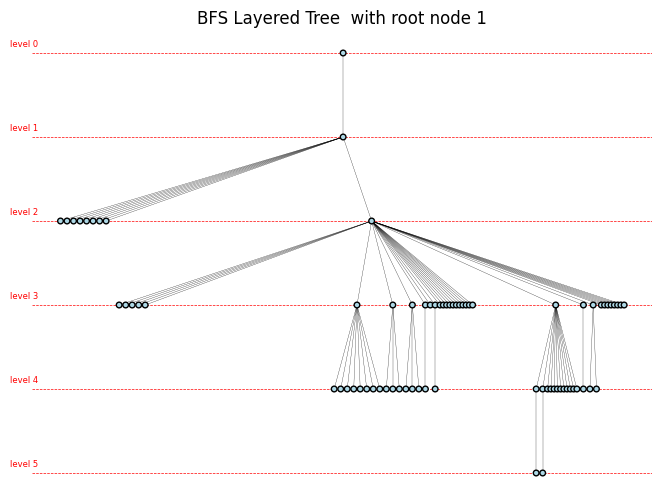

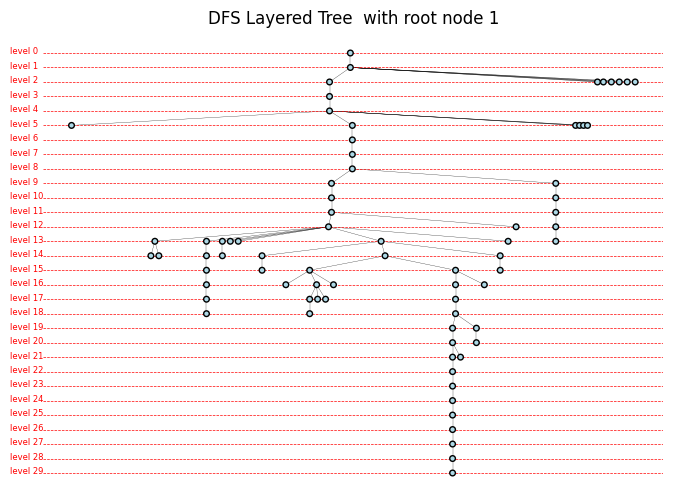

In [38]:
# choosing the graph and the root node
file_name = data_name_2
graph = parse_dot_file(file_name)
root_node = "1"

#running bfs and dfs on the graph
bfs_result = bfs_tree(graph, root_node)
dfs_result = dfs_tree(graph, root_node)

# plotting the trees with level-based layout with the nodes ids
display_node_id = False # by default, it displays the node ids with display_node_id = True
draw_layered_tree(bfs_result, "BFS Layered Tree  with root node 1", display_node_id)
draw_layered_tree(dfs_result, "DFS Layered Tree  with root node 1", display_node_id) 

## step 3

In [ ]:
draw_colorful_force_directed_graph_fruchterman_reingold_inertia(
    file_name, 
    iterations=200,
    C=1.75,  
    convergence_threshold=0.001,
    display_node_id=False)

## step 4

## step 5

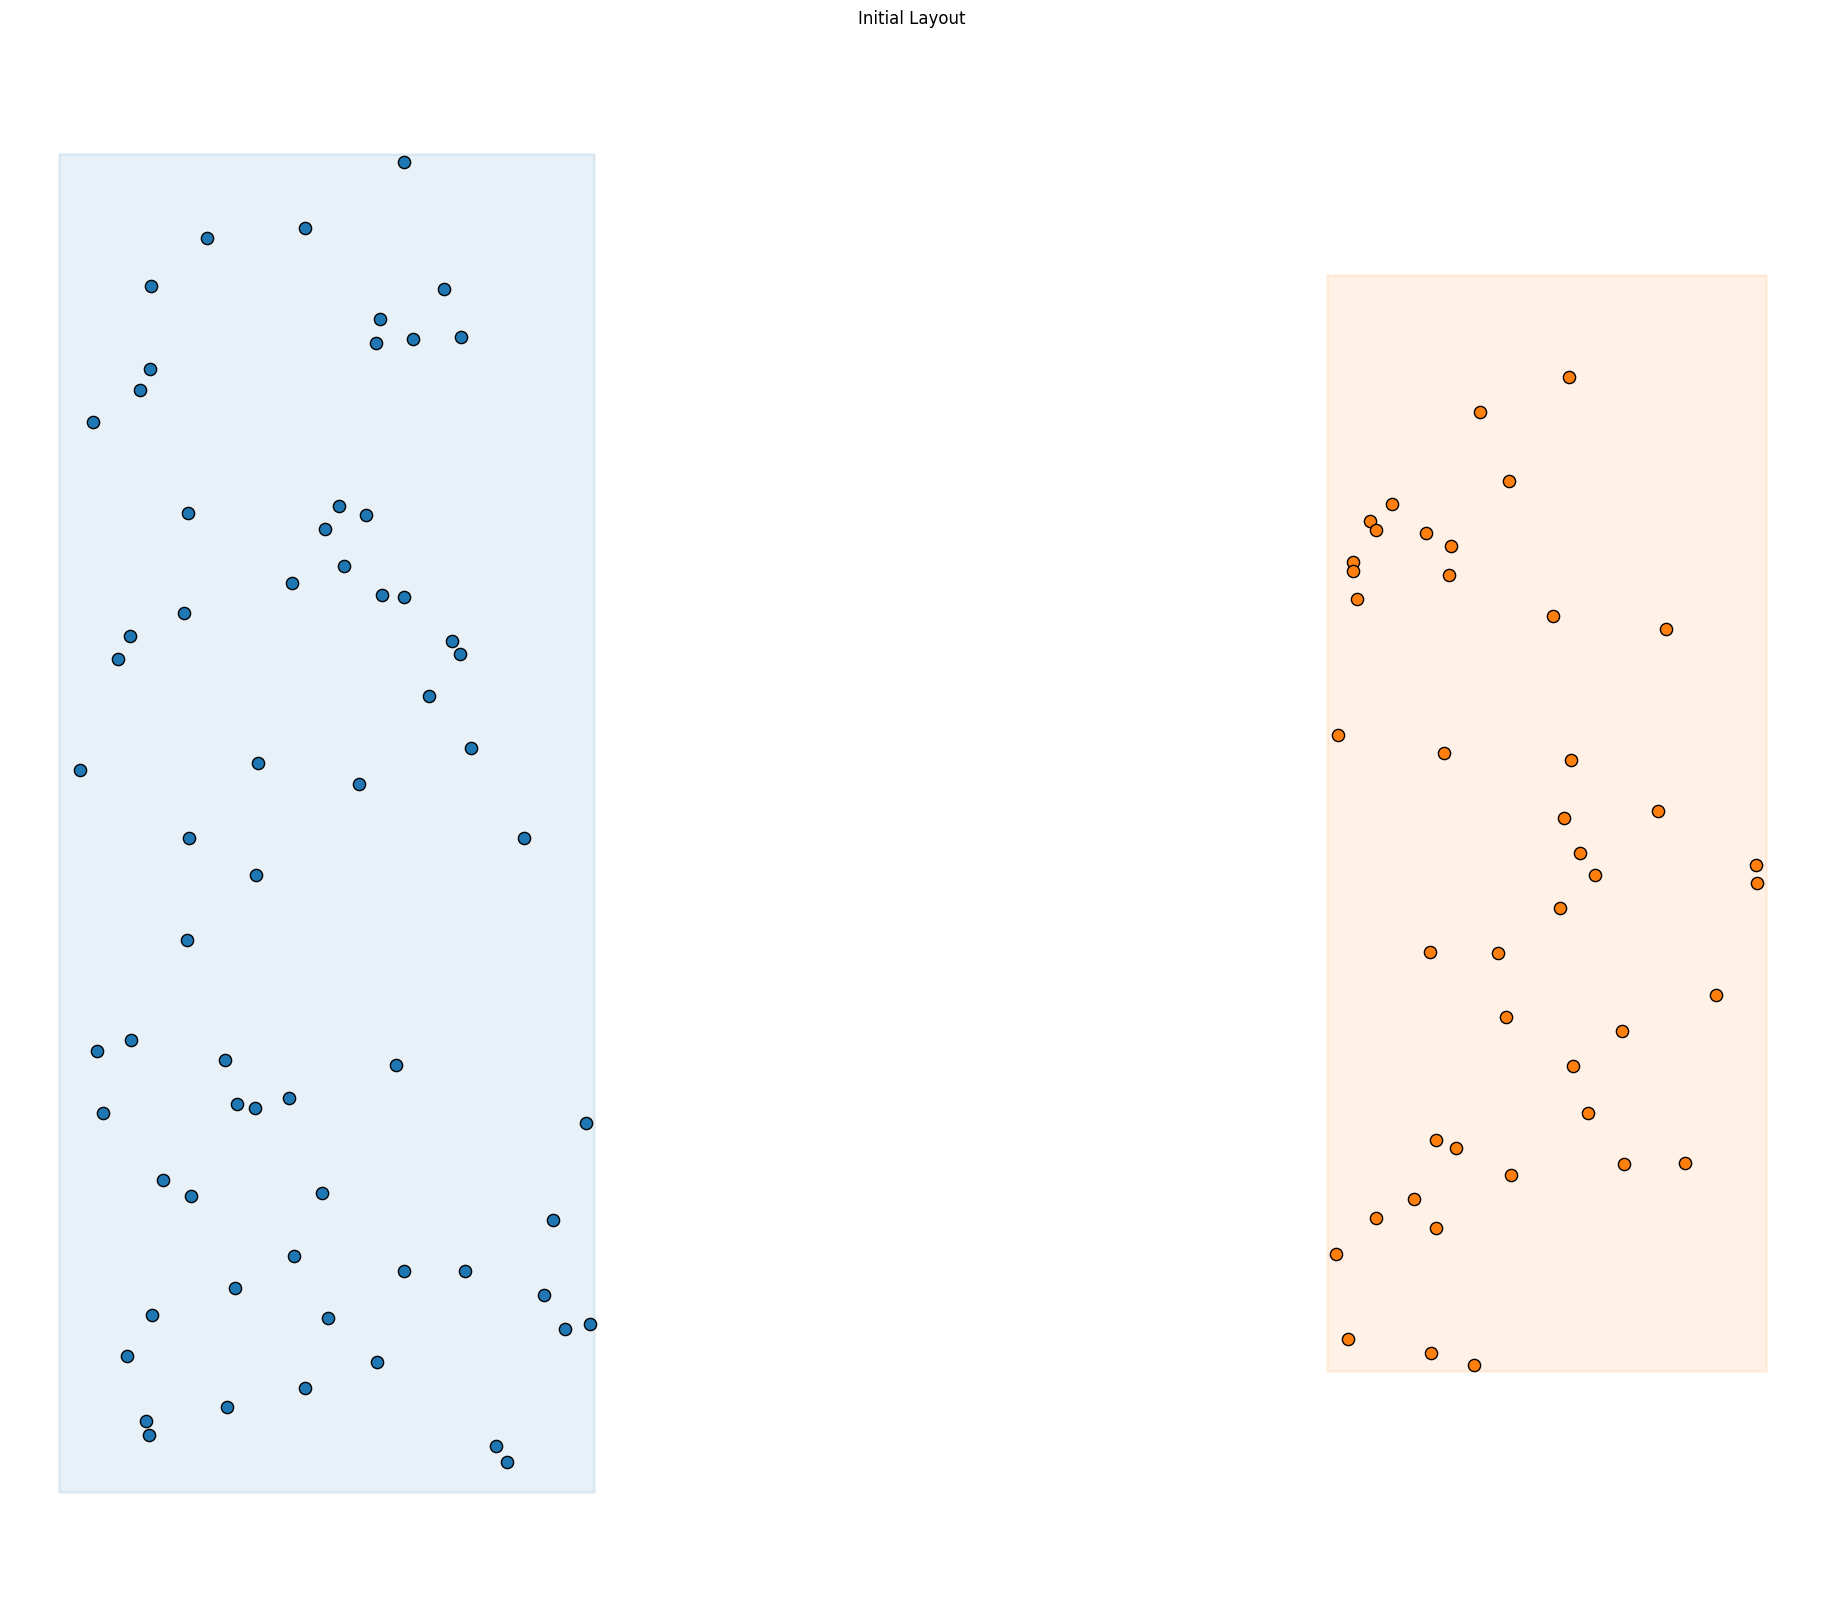

Subgraph 'Youngest Devonian Strata' converged at iteration 1 with max movement 0.000000
Subgraph 'Youngest Devonian Strata' newly converged at iteration 1
Subgraph 'Gap in the Sequence of Devonshi' converged at iteration 1 with max movement 0.000000
Subgraph 'Gap in the Sequence of Devonshi' newly converged at iteration 1


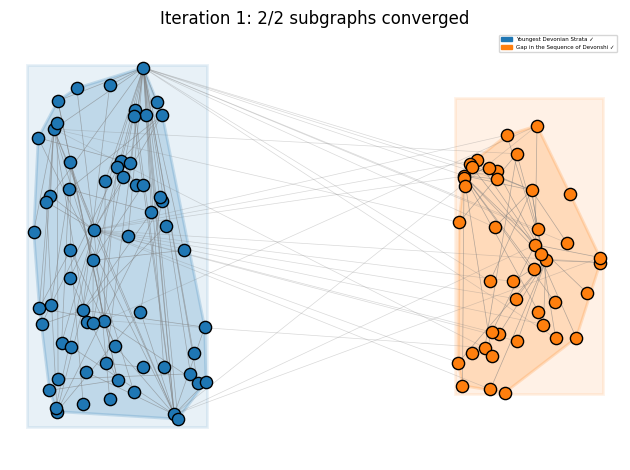

Saved final layout to devonshire_subgraphs_layout.png


<Figure size 640x480 with 0 Axes>

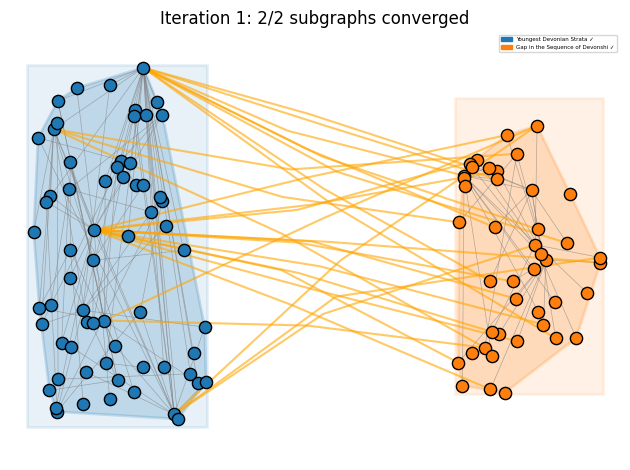

Applying smoothing pass 1/11 with kernel_width=3, sigma=0.8, iterations=1


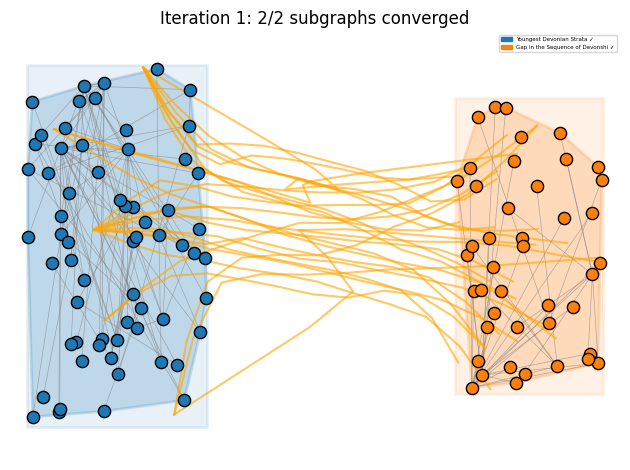

Applying smoothing pass 2/11 with kernel_width=5, sigma=1.0, iterations=1


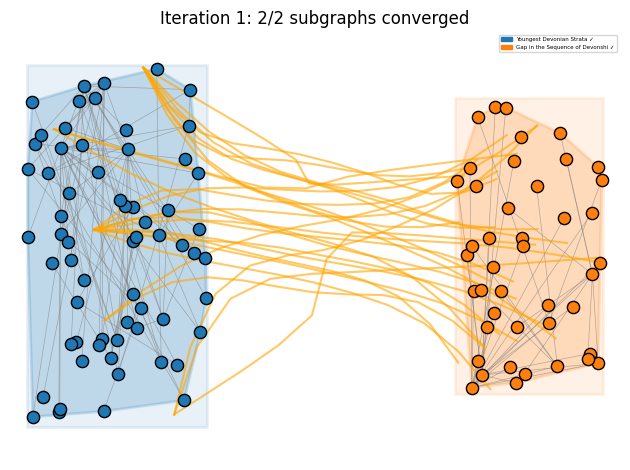

Applying smoothing pass 3/11 with kernel_width=7, sigma=1.2000000000000002, iterations=1


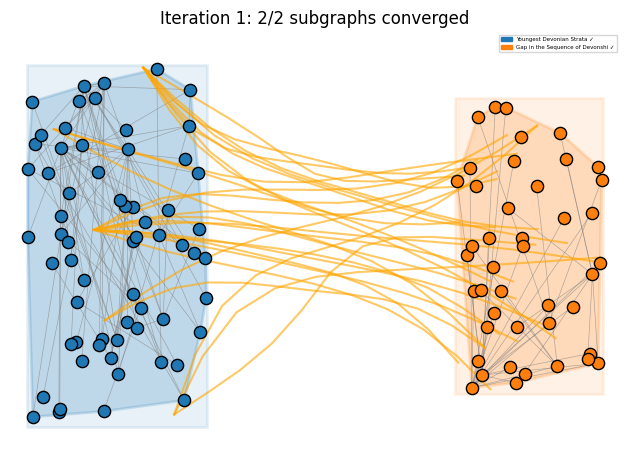

Applying smoothing pass 4/11 with kernel_width=9, sigma=1.4000000000000001, iterations=1


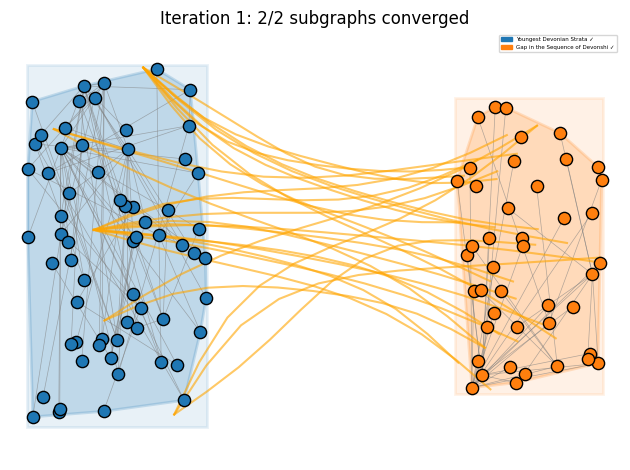

Applying smoothing pass 5/11 with kernel_width=11, sigma=1.6, iterations=1


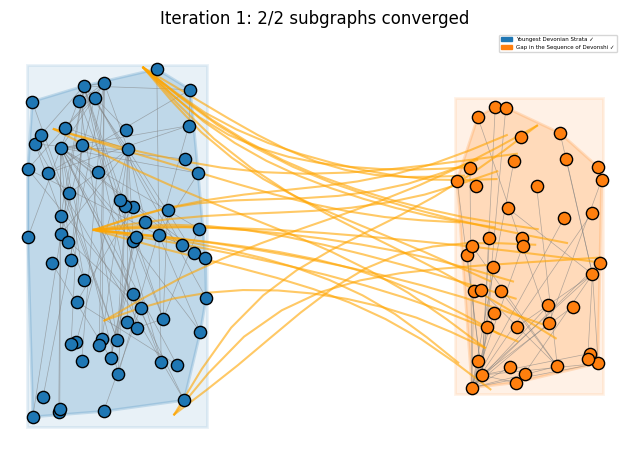

Applying smoothing pass 6/11 with kernel_width=13, sigma=1.8, iterations=1


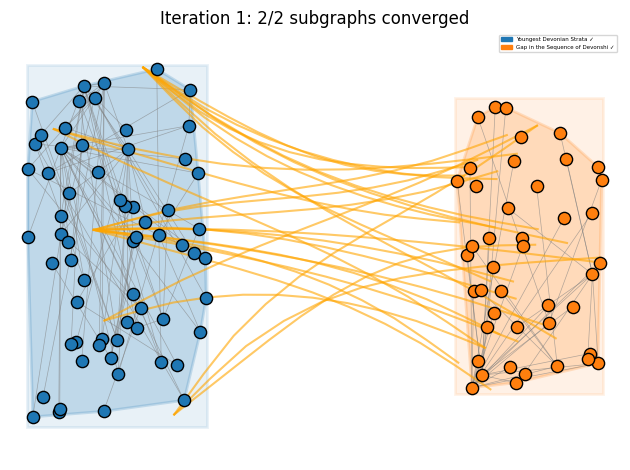

Applying smoothing pass 7/11 with kernel_width=15, sigma=2.0, iterations=1


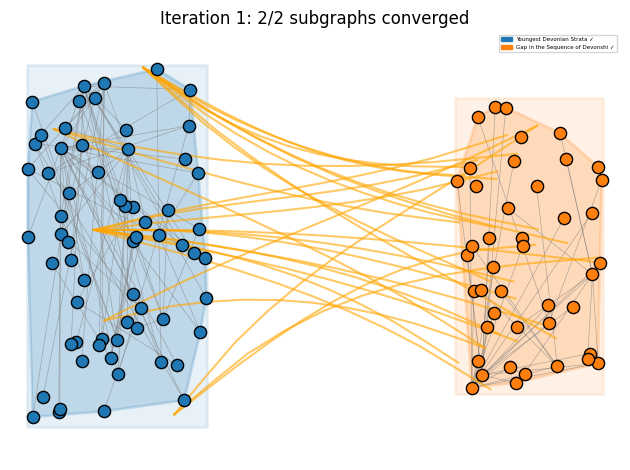

Applying smoothing pass 8/11 with kernel_width=17, sigma=2.2, iterations=1


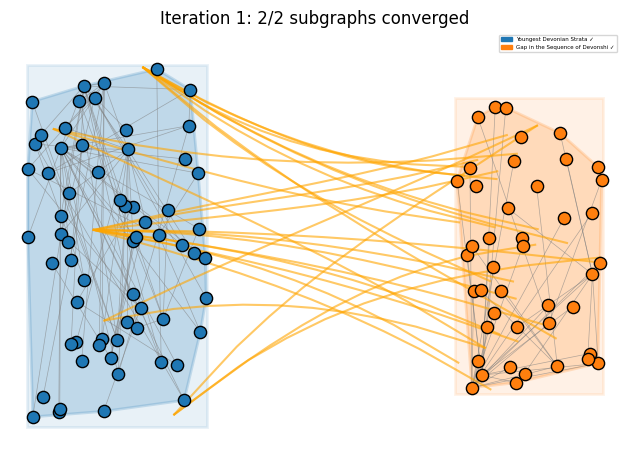

Applying smoothing pass 9/11 with kernel_width=19, sigma=2.4000000000000004, iterations=1


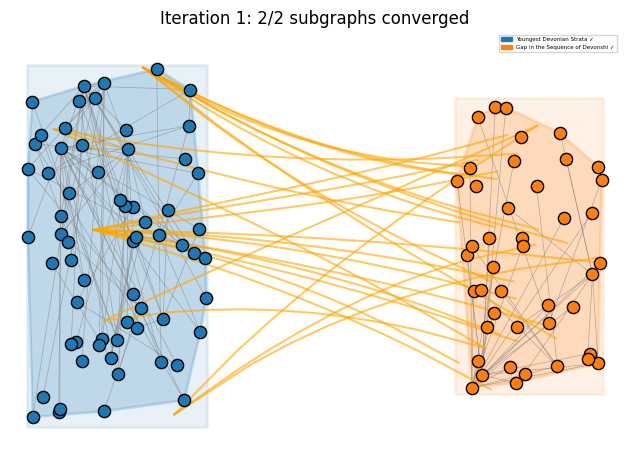

Applying smoothing pass 10/11 with kernel_width=21, sigma=2.6, iterations=1


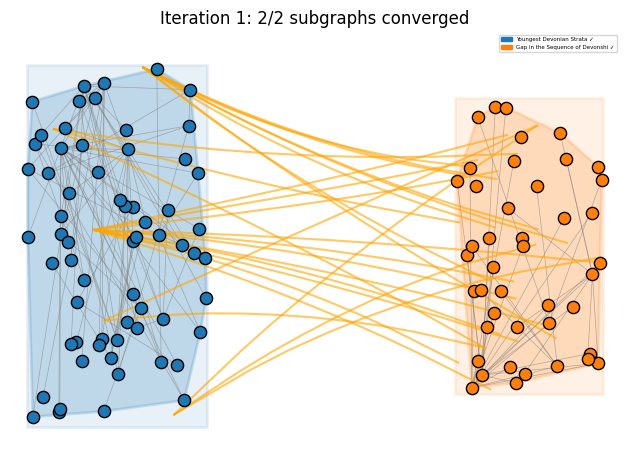

Applying smoothing pass 11/11 with kernel_width=23, sigma=2.8, iterations=1


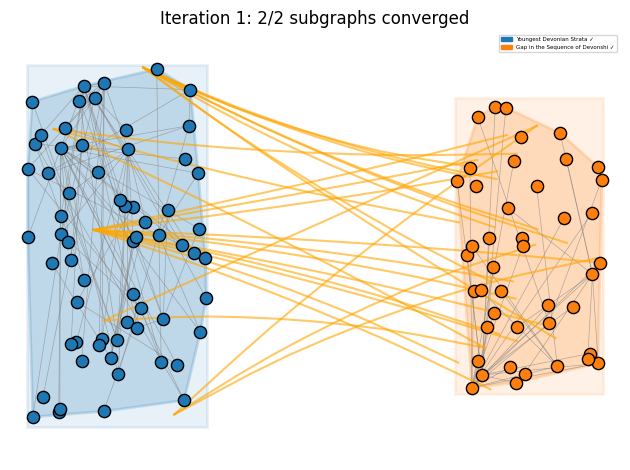

[({('n152', 'n144'): [array([13.68834831,  3.93117373]), array([7.2852989 , 3.72558038]), array([7.59735236, 3.66643332]), array([7.96218734, 3.69603607]), array([8.46128064, 3.80771336]), array([9.00652488, 4.17087331]), array([8.84594375, 3.98977574]), array([9.28606919, 3.78256802]), array([9.69527577, 3.69254089]), array([10.08941199,  3.64823889]), array([10.4810497 ,  3.66064572]), array([3.6530303 , 5.62231925])], ('n154', 'n149'): [array([15.91505099,  2.8509304 ]), array([7.94971591, 3.22845458]), array([8.24668857, 3.05759625]), array([8.59725244, 2.96208291]), array([9.00219258, 2.82681995]), array([9.5392239, 2.7629956]), array([9.74102244, 2.17194672]), array([9.52518118, 2.15387104]), array([10.00150064,  2.29194641]), array([10.41405465,  2.19956105]), array([10.79177233,  2.12080094]), array([4.62140423, 0.19514363])], ('n149', 'n331'): [array([4.62140423, 0.19514363]), array([5.45012957, 2.49289641]), array([6.36516566, 2.373444  ]), array([7.34548687, 2.40114827]), ar

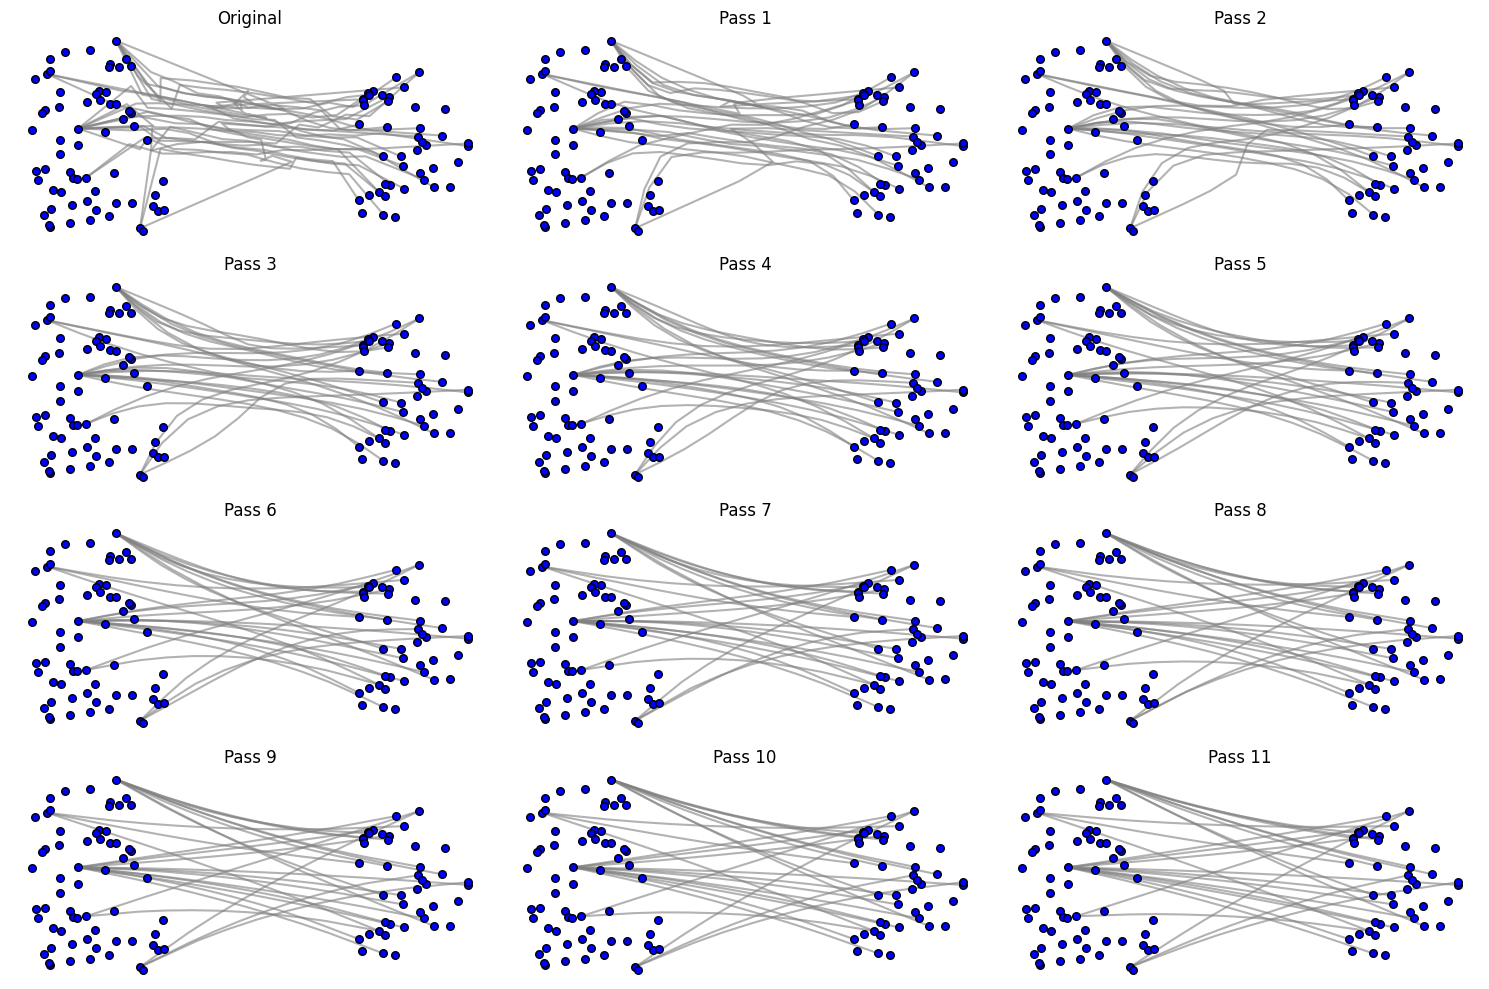

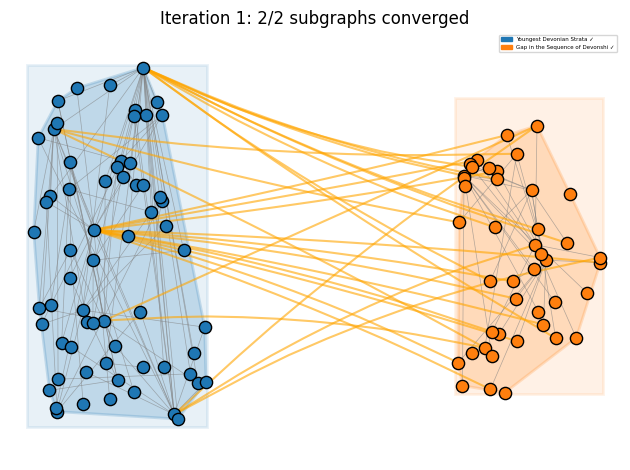

In [35]:
# Example usage
dot_file_path = "../Dataset/devonshiredebate_withclusters.dot"
subgraph_names = ["Youngest Devonian Strata", "Gap in the Sequence of Devonshi"]

# Process the DOT file and get subgraphs data
subgraphs_data = step5.process_dot_file_for_subgraphs(dot_file_path, subgraph_names)

# Visualize the subgraphs and get the graph and positions
G, pos, visualization_elements = step5.draw_colorful_FDG_FR_inertia_subgraphs(
    subgraphs_data,
    output_name="devonshire_subgraphs_layout.png",
    iterations=300,
    display_node_id=False,
    save_frames=False,
    output_dir="../Output_subgraphs",
    separation_factor=2.0,
    subgraph_spacing=1.5,
    convergence_threshold=0.0005
)

# Apply Force-Directed Edge Bundling (FDEB) to inter-cluster edges
cluster1_nodes = [node for node, attrs in subgraphs_data['subgraphs'][subgraph_names[0]]]
cluster2_nodes = [node for node, attrs in subgraphs_data['subgraphs'][subgraph_names[1]]]
bundled_edges = step5.apply_fdeb_to_inter_cluster_edges(G, pos, cluster1_nodes, cluster2_nodes)

# Visualize bundled edges
step5.actual_drawing_boundled(*visualization_elements, bundled_edges)

# Define the number of iterations
num_iterations = 11  # User-defined number of times the smoothing takes place

# Setting the parameters for the smoothing passes
fdeb_params = {'P': 10, 'S': 0.03, 'I': 15, 'compatibility_threshold': 0.06}

"""
Parameters meaning:
- P: number of control points per edge
- S: spring constant
- I: number of iterations for force-directed edge bundling to take place
- compatibility_threshold: threshold for edge compatibility
"""

# Call the edge smoothing function
final_smoothed_edges = step5.edge_smoothing_with_iterations(
    G, pos, cluster1_nodes, cluster2_nodes, iterations=num_iterations, fdeb_params=fdeb_params
)

# Visualize the final smoothed edges
step5.actual_drawing_boundled(*visualization_elements, final_smoothed_edges)

## step 6

### distance matrix

### mds

### t-sne

### isomap

## step 7